# Phase 2: Forecasting Model Validation and Testing

This notebook verifies and tests the implementation of the **Forecasting Model Module** (`models/forecasting_model.py`).

### Objectives:
1. **Load Processed Data**: Read the cleaned supply chain and inventory dataset.
2. **Import & Train Forecasting Model**: Load the `ForecastingModel` custom module and fit the Random Forest pipeline with automatic preprocessing and schema detection.
3. **Make Predictions**: Predict future demand on the dataset.
4. **Show Evaluation Metrics**: Assess the model's accuracy (MSE, RMSE, MAE, R²).
5. **Create Demand Visualization**: Compare actual demand versus predicted demand visually.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in python path to allow importing models
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project Root Path added to sys.path:", project_root)
print("Pandas Version:", pd.__version__)
print("Seaborn Version:", sns.__version__)

Project Root Path added to sys.path: d:\Kagglecource\Agentic-Inventory-Optimization-System
Pandas Version: 3.0.3
Seaborn Version: 0.13.2


## 1. Load Processed Data

We load the processed and cleaned dataset from `data/processed/cleaned_data.csv`. Let's inspect the columns, data types, and check the first few records.

In [2]:
data_path = os.path.join("..", "data", "processed", "cleaned_data.csv")
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Cleaned data file not found at: {data_path}. Please check file directory.")

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Columns and Data Types ---")
df.info()

print("\n--- First 5 Rows Preview ---")
df.head()

Dataset Shape: 99 rows, 15 columns

--- Columns and Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 99 non-null     str    
 1   Product              99 non-null     str    
 2   Category             99 non-null     str    
 3   Demand               99 non-null     int64  
 4   Order_Quantity       99 non-null     int64  
 5   Inventory_Level      99 non-null     int64  
 6   Price                99 non-null     float64
 7   Cost                 99 non-null     float64
 8   Warehouse            99 non-null     str    
 9   Region               99 non-null     str    
 10  Supplier             99 non-null     str    
 11  Lead_Time            99 non-null     float64
 12  Holding_Cost         99 non-null     float64
 13  Transportation_Cost  99 non-null     float64
 14  Storage_Capacity     99 non-null    

,Date,Product,Category,Demand,Order_Quantity,Inventory_Level,Price,Cost,Warehouse,Region,Supplier,Lead_Time,Holding_Cost,Transportation_Cost,Storage_Capacity
0,01-01-2023,Vitamin C Tablets,Supplement,108,124,140,120.0,70.0,Bengaluru Distribution Center,South,Alkem Laboratories,1.0,4.38,15.46,11000
1,01-01-2023,Iron Tablets,Supplement,101,116,131,120.0,75.0,Lucknow Distribution Center,North,Sun Pharma,1.0,4.30,10.59,8000
2,01-01-2023,Zinc Tablets,Supplement,109,125,141,100.0,60.0,Bengaluru Distribution Center,South,Sun Pharma,1.0,3.58,14.99,11000
3,01-01-2023,Zinc Tablets,Supplement,90,103,117,100.0,60.0,Mumbai Central Warehouse,West,Sun Pharama,3.0,3.77,22.89,12000
4,01-01-2023,Calcium Tablets,Supplement,57,65,74,150.0,90.0,Bengaluru Distribution Center,north,Torrent Pharma,4.0,4.48,19.12,11000


## 2. Import, Initialize and Train the Forecasting Model

We import `ForecastingModel` from `models.forecasting_model`, initialize it, and run the training process.

The class encapsulates a full scikit-learn pipeline including:
- Datetime feature extraction (`_extract_datetime_features`)
- Target/feature schema discovery (`_detect_target_and_features`)
- Numeric scaling & categorical one-hot encoding preprocessing pipelines
- A `RandomForestRegressor` regressor

The `.train()` method performs an internal 80/20 train/validation split, fits the pipelines, and computes model validation metrics.

In [3]:
from models.forecasting_model import ForecastingModel

# 1. Initialize the model
forecaster = ForecastingModel(random_state=42)
print("ForecastingModel initialized successfully.")

# 2. Train the model
print("Training the forecasting model...")
metrics = forecaster.train(data_path=data_path)

print("\n=== Model Training Completed ===")
print(f"Numeric features used: {forecaster.numeric_features}")
print(f"Categorical features used: {forecaster.categorical_features}")
print(f"Target column: {forecaster.target_col}")

print("\n--- Evaluation Metrics on Validation Split ---")
for metric_name, val in metrics.items():
    print(f" - {metric_name.upper():<5}: {val:.4f}")

ForecastingModel initialized successfully.
Training the forecasting model...

=== Model Training Completed ===
Numeric features used: ['Order_Quantity', 'Inventory_Level', 'Price', 'Cost', 'Lead_Time', 'Holding_Cost', 'Transportation_Cost', 'Storage_Capacity', 'Date_year', 'Date_month', 'Date_day', 'Date_dayofweek']
Categorical features used: ['Product', 'Category', 'Warehouse', 'Region', 'Supplier']
Target column: Demand

--- Evaluation Metrics on Validation Split ---
 - MSE  : 27.9024
 - RMSE : 5.2823
 - MAE  : 2.7115
 - R2   : 0.9737


## 3. Make Predictions

We can use the convenience method `predict_future_demand()` to run predictions on the input dataset and output a copy with a new `'predicted_demand'` column.

In [5]:
pred_df = forecaster.predict_future_demand(data_path=data_path)

print("\nPreview of Predictions:")
cols_to_show = [col for col in ['Date', 'Product', 'Category', forecaster.target_col, 'predicted_demand'] if col in pred_df.columns]
display(pred_df[cols_to_show].head(10))


Preview of Predictions:


,Date,Product,Category,Demand,predicted_demand
0,01-01-2023,Vitamin C Tablets,Supplement,108,108.34
1,01-01-2023,Iron Tablets,Supplement,101,101.45
2,01-01-2023,Zinc Tablets,Supplement,109,109.20
3,01-01-2023,Zinc Tablets,Supplement,90,89.42
4,01-01-2023,Calcium Tablets,Supplement,57,55.95
5,01-01-2023,Vitamin C Tablets,Supplement,107,107.55
6,01-01-2023,ORS Sachets,Medicine,60,59.13
7,01-01-2023,Antibiotic Syrup,Medicine,37,40.70
8,01-01-2023,Hand Sanitizer,Hygiene,129,128.72
9,01-01-2023,Hand Sanitizer,Hygiene,82,82.11


## 4. Demand Visualization

We visualize the prediction performance using three plots:
1. **Aggregate Demand Over Time**: We group predictions and actuals by Date to see how well the model tracks overall demand fluctuations.
2. **Actual vs Predicted Scatter Plot**: Evaluates line of perfect fit ($Y = \hat{Y}$).
3. **Residual Distribution Plot**: Shows whether errors are normally distributed around zero.

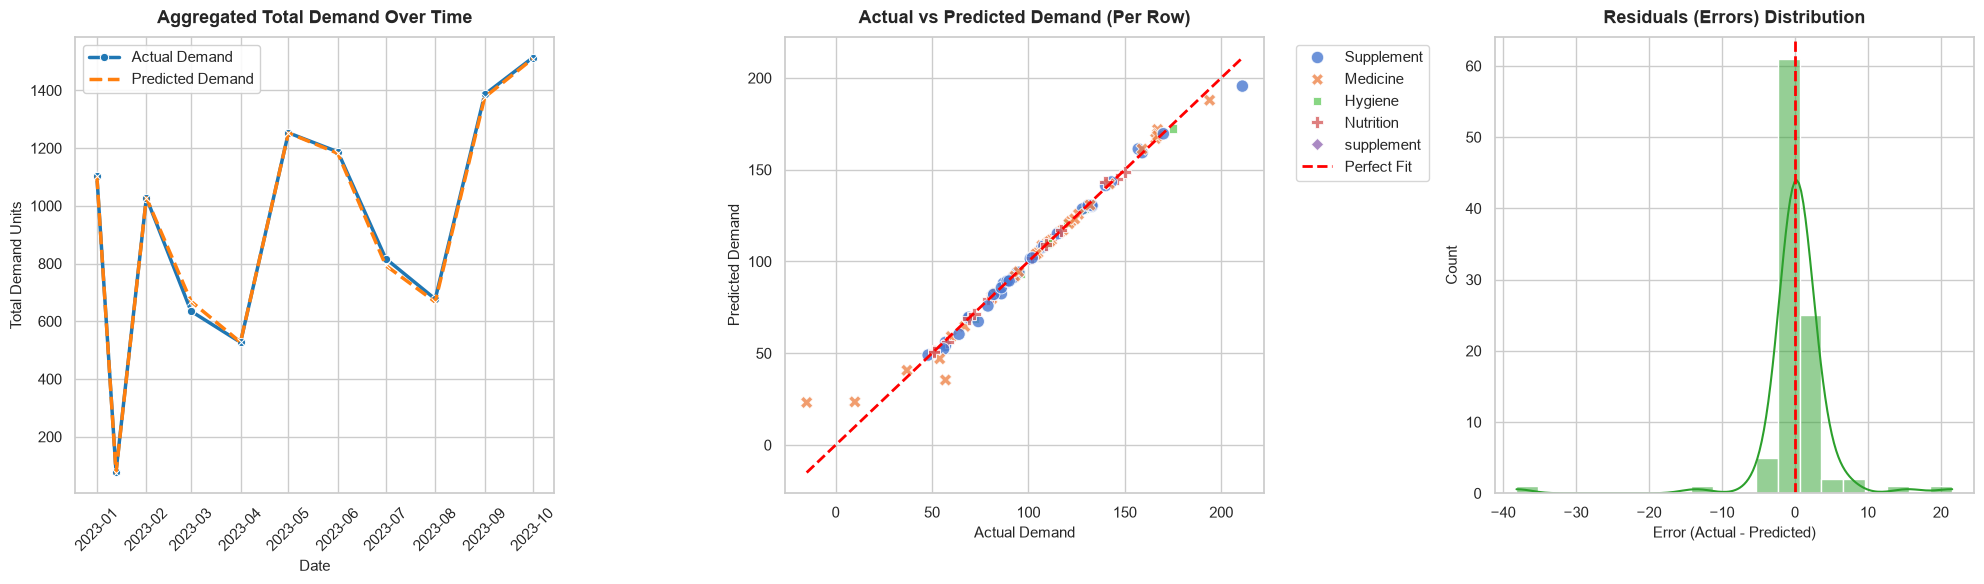

In [6]:
# Set styled plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "sans-serif"

# Create figures
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Pre-process dates for sorting and temporal plotting
temp_df = pred_df.copy()
temp_df['Date'] = pd.to_datetime(temp_df['Date'], dayfirst=False, errors='coerce')
temp_df = temp_df.sort_values('Date')

# Aggregated Daily Demand comparison
agg_df = temp_df.groupby('Date')[[forecaster.target_col, 'predicted_demand']].sum().reset_index()

# Plot 1: Line plot of aggregated demand
sns.lineplot(data=agg_df, x='Date', y=forecaster.target_col, label='Actual Demand', marker='o', ax=axes[0], color='#1f77b4', linewidth=2.5)
sns.lineplot(data=agg_df, x='Date', y='predicted_demand', label='Predicted Demand', marker='x', linestyle='--', ax=axes[0], color='#ff7f0e', linewidth=2.5)
axes[0].set_title("Aggregated Total Demand Over Time", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Date", fontsize=11)
axes[0].set_ylabel("Total Demand Units", fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(frameon=True, facecolor='white', framealpha=0.9)

# Plot 2: Scatter plot of Actual vs Predicted
sns.scatterplot(data=pred_df, x=forecaster.target_col, y='predicted_demand', hue='Category', style='Category', alpha=0.8, s=80, ax=axes[1])
max_val = max(pred_df[forecaster.target_col].max(), pred_df['predicted_demand'].max())
min_val = min(pred_df[forecaster.target_col].min(), pred_df['predicted_demand'].min())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')
axes[1].set_title("Actual vs Predicted Demand (Per Row)", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Actual Demand", fontsize=11)
axes[1].set_ylabel("Predicted Demand", fontsize=11)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True) if len(pred_df['Category'].unique()) < 10 else axes[1].legend().remove()

# Plot 3: Residuals histogram
residuals = pred_df[forecaster.target_col] - pred_df['predicted_demand']
sns.histplot(residuals, kde=True, ax=axes[2], color='#2ca02c', bins=20)
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title("Residuals (Errors) Distribution", fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel("Error (Actual - Predicted)", fontsize=11)
axes[2].set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()